In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Configurações ---
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 10
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10
FINE_TUNE_AT = -20

# --- Callbacks ---
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

# --- Caminhos dos Arquivos ---
H5_MODEL_PATH = "cifar10_EfficientNetB0_small_finetuned.keras"
TFLITE_MODEL_PATH = "cifar10_EfficientNetB0_small_finetuned.tflite"
TFLITE_INT8_MODEL_PATH = "cifar10_EfficientNetB0_small_finetuned_int8.tflite"

In [2]:
def load_and_preprocess_data():
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()

    y_train = to_categorical(y_train, NUM_CLASSES)
    y_test = to_categorical(y_test, NUM_CLASSES)

    def format_image(image, label):
        image = tf.cast(image, tf.float32)
        image = tf.image.resize(image, (INPUT_SHAPE[0], INPUT_SHAPE[1]))
        image = preprocess_input(image)
        return image, label

    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_ds = (
        train_ds.shuffle(buffer_size=1024)
        .map(format_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
    test_ds = (
        test_ds.map(format_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    return train_ds, test_ds

def build_model():
    base_model = EfficientNetB0(
        input_shape=INPUT_SHAPE,
        include_top=False,
        weights='imagenet',
        pooling='avg'  # Equivalente ao GlobalAveragePooling2D
    )
    base_model.trainable = False

    inputs = Input(shape=INPUT_SHAPE)

    x = base_model(inputs, training=False)
    x = Dropout(0.2)(x)  # Mesmo dropout usado no cats/dogs
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base_model


def plot_training_history(history, history_fine):
    """
    Plota as métricas de acurácia e perda do treinamento inicial e do fine-tuning.
    """
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']

    initial_epochs = len(history.history['accuracy'])
    total_epochs = len(acc)

    plt.figure(figsize=(14, 6))

    # Gráfico de Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Acurácia de Treino')
    plt.plot(val_acc, label='Acurácia de Validação')
    plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Início do Fine-Tuning')
    plt.title('Acurácia do Modelo')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.ylim([min(plt.ylim()), 1])
    plt.legend(loc='lower right')

    # Gráfico de Perda
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Perda de Treino')
    plt.plot(val_loss, label='Perda de Validação')
    plt.axvline(initial_epochs - 1, color='gray', linestyle='--', label='Início do Fine-Tuning')
    plt.title('Perda do Modelo')
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()




def save_tflite_model(model, path, is_quantized=False, representative_ds=None):
    """
    Converte um modelo Keras para TFLite, com configuração estrita para
    quantização full-integer.
    """
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if is_quantized:
        if representative_ds is None:
            raise ValueError("representative_dataset é necessário para quantização.")

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_ds
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        converter._experimental_new_quantizer = True

    tflite_model = converter.convert()

    with open(path, 'wb') as f:
        f.write(tflite_model)
    print(f"Modelo salvo em {path}")

In [3]:
# --- 1. Carregar Dados ---
train_ds, test_ds = load_and_preprocess_data()

# --- 2. Construir Modelo ---
model, base_model = build_model()
model.summary()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [4]:
# --- 3. Treinamento Inicial (Feature Extraction) ---
print("\n--- Iniciando Treinamento Inicial ---")
model.compile(
    optimizer=AdamW(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS,
    validation_data=test_ds,
    callbacks=[early_stopping, reduce_lr]
)

loss, accuracy = model.evaluate(test_ds)
print(f"\nAcurácia (Transfer Learning): {accuracy * 100:.2f}%")



--- Iniciando Treinamento Inicial ---
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 104ms/step - accuracy: 0.7613 - loss: 0.7699 - val_accuracy: 0.8866 - val_loss: 0.3429 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.8770 - loss: 0.3674 - val_accuracy: 0.8964 - val_loss: 0.3105 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.8888 - loss: 0.3289 - val_accuracy: 0.9006 - val_loss: 0.2954 - learning_rate: 0.0010
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.8902 - loss: 0.3179 - val_accuracy: 0.9044 - val_loss: 0.2872 - learning_rate: 0.0010
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.8935 - loss: 0.3093 - val_accuracy: 0.9063 - val_loss: 0.2816 - learning_rate: 0.0010
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.8945 - loss: 0.3010 - val_accuracy: 0.9076 - val_loss: 0.2790 - learning_rate: 0.0010
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━

In [5]:
# --- 4. Fine-Tuning ---
print("\n--- Iniciando Fine-Tuning ---")
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=AdamW(learning_rate=LEARNING_RATE / 10, weight_decay=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_start_epoch = history.epoch[-1] + 1
total_epochs = fine_tune_start_epoch + FINE_TUNE_EPOCHS +1

history_fine = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=fine_tune_start_epoch,
    validation_data=test_ds,
    callbacks=[early_stopping, reduce_lr]
)

loss, accuracy = model.evaluate(test_ds)
print(f"\nAcurácia Final: {accuracy * 100:.2f}%")


--- Iniciando Fine-Tuning ---
Epoch 11/21
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 110ms/step - accuracy: 0.8741 - loss: 0.3685 - val_accuracy: 0.9203 - val_loss: 0.2388 - learning_rate: 1.0000e-04
Epoch 12/21
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 82ms/step - accuracy: 0.9155 - loss: 0.2403 - val_accuracy: 0.9289 - val_loss: 0.2115 - learning_rate: 1.0000e-04
Epoch 13/21
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9314 - loss: 0.1983 - val_accuracy: 0.9359 - val_loss: 0.2012 - learning_rate: 1.0000e-04
Epoch 14/21
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9445 - loss: 0.1599 - val_accuracy: 0.9384 - val_loss: 0.1875 - learning_rate: 1.0000e-04
Epoch 15/21
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9528 - loss: 0.1372 - val_accuracy: 0.9390 - val_loss: 0.1823 - learning_rate: 1.0000e-04
Epoch 16/21
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.9586 - loss: 0.1195 - val_accuracy: 0.9409 - val_loss: 0.1795 - learning_rate: 1.0000e-04
Epoch 17/21


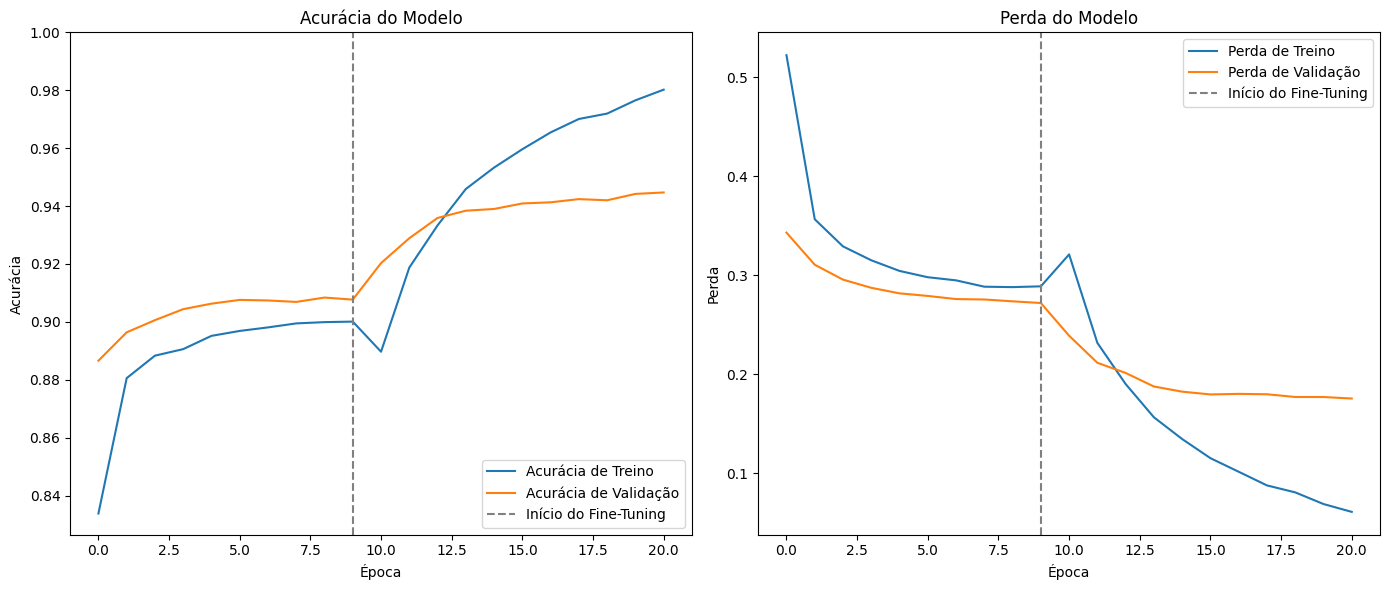

In [6]:
plot_training_history(history, history_fine)

In [7]:
# --- 5. Salvar Modelos ---
model.save(H5_MODEL_PATH)
print(f"Modelo Keras salvo em {H5_MODEL_PATH}")

save_tflite_model(model, TFLITE_MODEL_PATH)

Modelo Keras salvo em cifar10_EfficientNetB0_small_finetuned.keras
Saved artifact at '/tmp/tmpkhbosekl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_239')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135301820735248: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135301820737552: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135301844477776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844478736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844478352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844479504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844477200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844479312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844481424: TensorSpec(shape=(), dtype=tf.resource, name=No

In [8]:
# --- 6. Quantização INT8 ---
def representative_dataset_gen():
    """
    Gera um dataset representativo usando uma amostra aleatória do
    conjunto de treinamento para uma calibração mais robusta.
    """
    (x_train, _), _ = cifar10.load_data()

    num_calibration_samples = 20 # Hiperparâmetro: um valor robusto

    # Gera índices aleatórios para garantir uma amostra diversificada
    indices = np.random.choice(x_train.shape[0], num_calibration_samples, replace=False)

    for i in indices:
        image = x_train[i].astype(np.float32)
        image_resized = tf.image.resize(image, (INPUT_SHAPE[0], INPUT_SHAPE[1]))
        image_preprocessed = preprocess_input(image_resized)
        yield [np.expand_dims(image_preprocessed, axis=0)]

save_tflite_model(
    model,
    TFLITE_INT8_MODEL_PATH,
    is_quantized=True,
    representative_ds=representative_dataset_gen,

)

print("\n--- Comparação de Tamanhos ---")
print(f"  Keras (.keras): {os.path.getsize(H5_MODEL_PATH) / (1024*1024):.2f} MB")
print(f"  TFLite (FP32):  {os.path.getsize(TFLITE_MODEL_PATH) / (1024*1024):.2f} MB")
print(f"  TFLite (INT8):  {os.path.getsize(TFLITE_INT8_MODEL_PATH) / (1024*1024):.2f} MB")

Saved artifact at '/tmp/tmp550hmc_u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_239')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135301820735248: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135301820737552: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135301844477776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844478736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844478352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844479504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844477200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844479312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844481424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135301844481616: TensorSpec(shape=(), dtype=tf.resource, name

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Modelo salvo em cifar10_EfficientNetB0_small_finetuned_int8.tflite

--- Comparação de Tamanhos ---
  Keras (.keras): 25.03 MB
  TFLite (FP32):  15.34 MB
  TFLite (INT8):  4.69 MB


In [9]:
import tensorflow as tf
import numpy as np


def evaluate_tflite_int8_model(model_path, num_images_to_test=None):
    print(f"\nAvaliando modelo INT8: {model_path}")

    (_, _), (x_test, y_test) = cifar10.load_data()

    interpreter = tf.lite.Interpreter(
    model_path=model_path,
    experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
)


    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    input_shape = input_details['shape']
    height, width = input_shape[1], input_shape[2]

    correct_predictions = 0
    total_images = len(x_test) if num_images_to_test is None else num_images_to_test

    for i in range(total_images):
        image_float32 = x_test[i].astype(np.float32)
        image_resized = tf.image.resize(image_float32, [height, width])
        image_preprocessed = preprocess_input(image_resized)

        image_quantized = (image_preprocessed / input_scale) + input_zero_point
        image_quantized = np.expand_dims(image_quantized.numpy().astype(input_details["dtype"]), axis=0)

        interpreter.set_tensor(input_details['index'], image_quantized)
        interpreter.invoke()

        output_data = interpreter.get_tensor(output_details['index'])
        output_dequantized = (output_data.astype(np.float32) - output_zero_point) * output_scale

        predicted_label = np.argmax(output_dequantized)
        true_label = y_test[i][0]

        if predicted_label == true_label:
            correct_predictions += 1

    accuracy = (correct_predictions / total_images) * 100
    print(f"Acurácia do modelo TFLite INT8: {accuracy:.2f}% ({correct_predictions}/{total_images})")
    return accuracy



In [10]:
evaluate_tflite_int8_model(TFLITE_INT8_MODEL_PATH)


Avaliando modelo INT8: cifar10_EfficientNetB0_small_finetuned_int8.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Acurácia do modelo TFLite INT8: 80.19% (8019/10000)


80.19